In [1]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt


In [20]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares

# Generate data without randomness
x = np.linspace(0, 10, 20)
y = 3.0 * x + 2.0  # true slope=3, intercept=2 (no noise)
yerr = np.ones_like(y)  # constant uncertainty

# Define model function
def model(x, m, c):
    return m * x + c

# Define cost function for least-squares
least_squares = LeastSquares(x, y, yerr, model)

# Initialize Minuit with starting values
m = Minuit(least_squares, m=1, c=0)

# Run minimization
m.migrad()  
m.hesse()   # estimate parameter uncertainties

# Print results
print(m.values)      # best-fit parameters
print(m.errors)      # parameter uncertainties
print(f"m: {m.values['m']:.30f}")
print(f"c: {m.values['c']:.30f}")


<ValueView m=2.999999999999889 c=1.9999999999994236>
<ErrorView m=0.07367883975013825 c=0.43094580361443674>
m: 2.999999999999888977697537484346
c: 1.999999999999423572205614618724


In [10]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares

# Generate data without randomness
x = np.linspace(0, 10, 20)
y = 3.0 * x + 2.0  # true slope=3, intercept=2 (no noise)
yerr = np.ones_like(y)  # constant uncertainty

# Define model function
def model(x, m, c):
    return m * x + c

# Define cost function for least-squares
least_squares = LeastSquares(x, y, yerr, model)

# Initialize Minuit with starting values
m = Minuit(least_squares, m=1, c=0)

# Run minimization
m.migrad()  
m.migrad()
m.migrad()
m.migrad()  
m.migrad()
m.migrad()
# m.hesse()
m.hesse()
m.minos(cl=0.99)
   # estimate parameter uncertainties

# Print results
print(m.values)      # best-fit parameters
print(m.errors)      # parameter uncertainties

print(f"m: {m.values['m']:.30f}")
print(f"c: {m.values['c']:.30f}")

diff = 2 - m.values['c']

print(f"diff: {diff:.3e}")

<ValueView m=3.0 c=2.0000000000000013>
<ErrorView m=0.07367883976236686 c=0.4309458036907209>
m: 3.000000000000000000000000000000
c: 2.000000000000001332267629550188
diff: -1.332e-15


In [4]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares

# Generate data without randomness
x = np.linspace(0, 10, 20)
y = 3.0 * x + 2.0  # true slope=3, intercept=2 (no noise)
yerr = np.ones_like(y)  # constant uncertainty

# Define model function
def model(x, m, c):
    return m * x + c

# Define cost function for least-squares
least_squares = LeastSquares(x, y, yerr, model)

# Initialize Minuit with starting values
m = Minuit(least_squares, m=1, c=0)

# Run minimization
m.migrad()  
m.migrad()
m.migrad()
m.hesse()

m.minos(cl=0.99)

   # estimate parameter uncertainties

# Print results
print(m.values)      # best-fit parameters
print(m.errors)      # parameter uncertainties

print(f"m: {m.values['m']:.30f}")
print(f"c: {m.values['c']:.30f}")

diff = 2 - m.values['c']

print(f"diff: {diff:.3e}")

<ValueView m=3.0 c=2.0000000000000013>
<ErrorView m=0.07367883976236686 c=0.4309458036907209>
m: 3.000000000000000000000000000000
c: 2.000000000000001332267629550188
diff: -1.332e-15


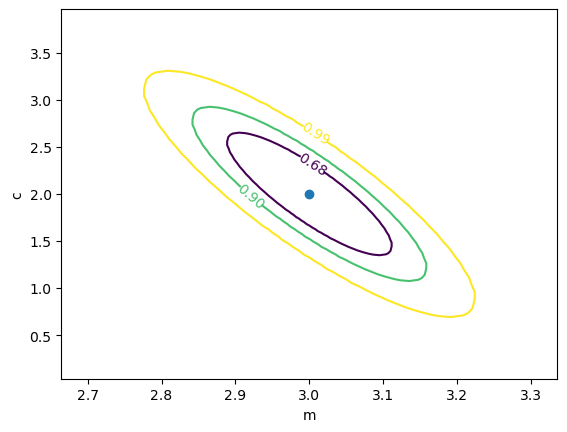

In [3]:
param1 = 'm'
param2 = 'c'

def zoom(factor=1.2):
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xmid = (xlim[0] + xlim[1]) / 2
    ymid = (ylim[0] + ylim[1]) / 2

    xsize = (xlim[1] - xlim[0]) * factor
    ysize = (ylim[1] - ylim[0]) * factor

    ax.set_xlim([xmid - xsize/2, xmid + xsize/2])
    ax.set_ylim([ymid - ysize/2, ymid + ysize/2])


m.draw_mncontour(param1, param2, cl = [0.68, 0.9, 0.99])
plt.plot(m.values[param1], m.values[param2], 'o')
zoom(1.5)   
plt.savefig(f'contour_{param1}_{param2}.pdf')

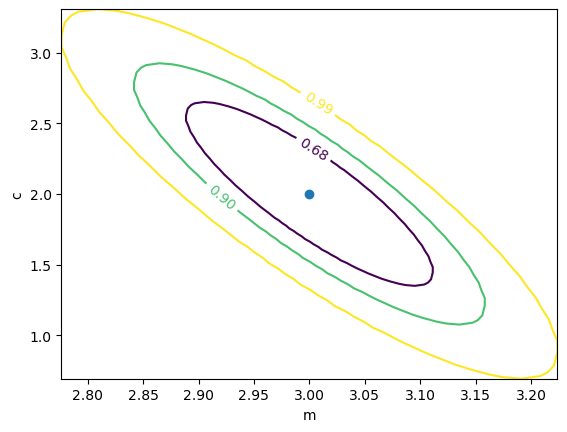

In [4]:
param1 = 'm'
param2 = 'c'

m.draw_mncontour(param1, param2, cl = [0.68, 0.9, 0.99])
plt.plot(m.values[param1], m.values[param2], 'o')
# plt.xlim(m.values[param1]*0.1, m.values[param1]*2)
# plt.ylim(m.values[param2]*0.1, m.values[param2]*2)
plt.savefig(f'contour_{param1}_{param2}.pdf')